<a href="https://colab.research.google.com/github/helonayala/sysid/blob/main/narmax_activity_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 2 - Solution

NARX model for the ball and hoop dataset.

## Imports, functions, and classes

In [1]:
# Imports and sysid course library
import numpy as np
import matplotlib.pyplot as plt

# --- Install/import the sysid course library (works locally and on Google Colab) ---
try:
    from sysid import NARX, readData
except ImportError:
    !pip install -q git+https://github.com/helonayala/sysid.git
    from sysid import NARX, readData


## Read BAH data

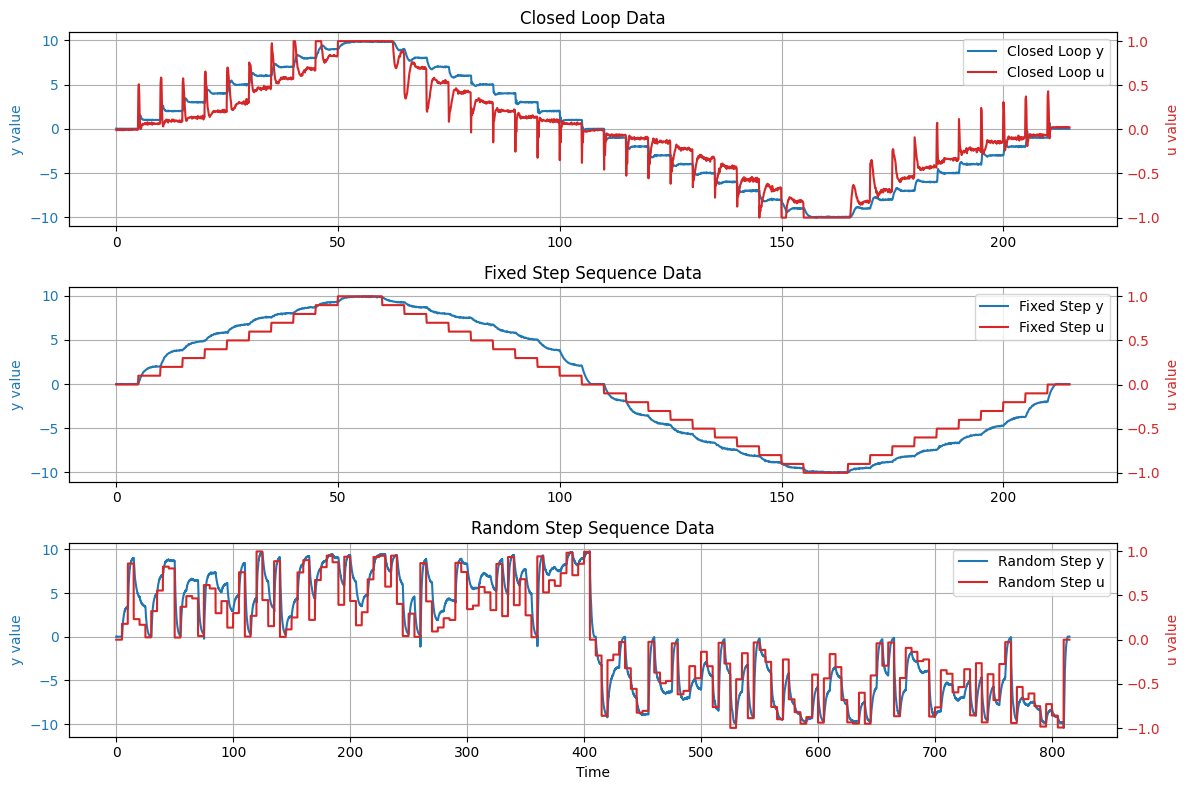

In [2]:
# Load our original ball-and-hoop datasets (y, u, time)
yt1, ut1, timet1 = readData("ball_and_hoop", "closedLoop")          # closed loop
yt2, ut2, timet2 = readData("ball_and_hoop", "fixedStepSequence")   # fixed step
ye,  ue,  timee  = readData("ball_and_hoop", "randomStepSequence")  # random step (estimation)

# Plotting the loaded data with two y-axes
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# Closed Loop Data
ax1 = axes[0]
ax1.plot(timet1, yt1, label='Closed Loop y', color='tab:blue')
ax1.set_ylabel('y value', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_title('Closed Loop Data')
ax1.grid(True)
ax2 = ax1.twinx()
ax2.plot(timet1, ut1, label='Closed Loop u', color='tab:red')
ax2.set_ylabel('u value', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')


# Fixed Step Sequence Data
ax1 = axes[1]
ax1.plot(timet2, yt2, label='Fixed Step y', color='tab:blue')
ax1.set_ylabel('y value', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_title('Fixed Step Sequence Data')
ax1.grid(True)
ax2 = ax1.twinx()
ax2.plot(timet2, ut2, label='Fixed Step u', color='tab:red')
ax2.set_ylabel('u value', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')


# Random Step Sequence Data
ax1 = axes[2]
ax1.plot(timee, ye, label='Random Step y', color='tab:blue')
ax1.set_ylabel('y value', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_title('Random Step Sequence Data')
ax1.set_xlabel('Time')
ax1.grid(True)
ax2 = ax1.twinx()
ax2.plot(timee, ue, label='Random Step u', color='tab:red')
ax2.set_ylabel('u value', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')


plt.tight_layout()
plt.show()

## Define model parameters, call constructor, and run estimation

In [3]:
no_of_terms = 10
nu_model = 10
ny_model = 10
poly_order_model = 3

# 3. Instantiate and fit the NARX model
narx_model = NARX(nu=nu_model, ny=ny_model, poly_order_l=poly_order_model, n_components=no_of_terms)
narx_model.fit(ue, ye)

narx_model.print()


NARX model — selected terms and parameters
Max lag: 10  (ny=10, nu=10, l=3)
#    Term                                theta     ERR (%)
-------------------------------------------------------
1    y(k-1)                             1.0916   99.958062
2    u(k-1)                             0.9244    0.021224
3    y(k-1)u(k-1)u(k-1)                -0.2586    0.006090
4    y(k-5)                            -0.1247    0.000387
5    y(k-5)u(k-1)u(k-1)                 0.1608    0.000397
6    u(k-1)u(k-1)u(k-3)                 0.6751    0.000304
7    u(k-3)                            -0.3318    0.000611
8    y(k-2)y(k-2)u(k-1)                 0.0508    0.000149
9    y(k-1)y(k-2)u(k-1)                -0.0506    0.000269
10   u(k-1)u(k-1)                      -0.0162    0.000131
-------------------------------------------------------
Total ERR explained:                 99.987624%


## Free-Run (FR) Simulation

In [4]:
max_lag = narx_model._max_lag_internal_

# estimation, not so difficult
ye_fr = ye[max_lag:] # Target for the FR part
ye_hat = narx_model.predict(ue, y_history_for_lags_or_osa=ye[:max_lag], mode='FR')

# test 1, unseen data
yt1_fr = yt1[max_lag:] # Target for the FR part
yt1_hat = narx_model.predict(ut1, y_history_for_lags_or_osa=yt1[:max_lag], mode='FR')

# test 2, unseen data
yt2_fr = yt2[max_lag:] # Target for the FR part
yt2_hat = narx_model.predict(ut2, y_history_for_lags_or_osa=yt2[:max_lag], mode='FR')

Starting Free-Run Simulation for 8140 steps...


FR Simulation:   0%|          | 0/8140 [00:00<?, ?step/s]

Starting Free-Run Simulation for 2140 steps...


FR Simulation:   0%|          | 0/2140 [00:00<?, ?step/s]

Starting Free-Run Simulation for 2140 steps...


FR Simulation:   0%|          | 0/2140 [00:00<?, ?step/s]

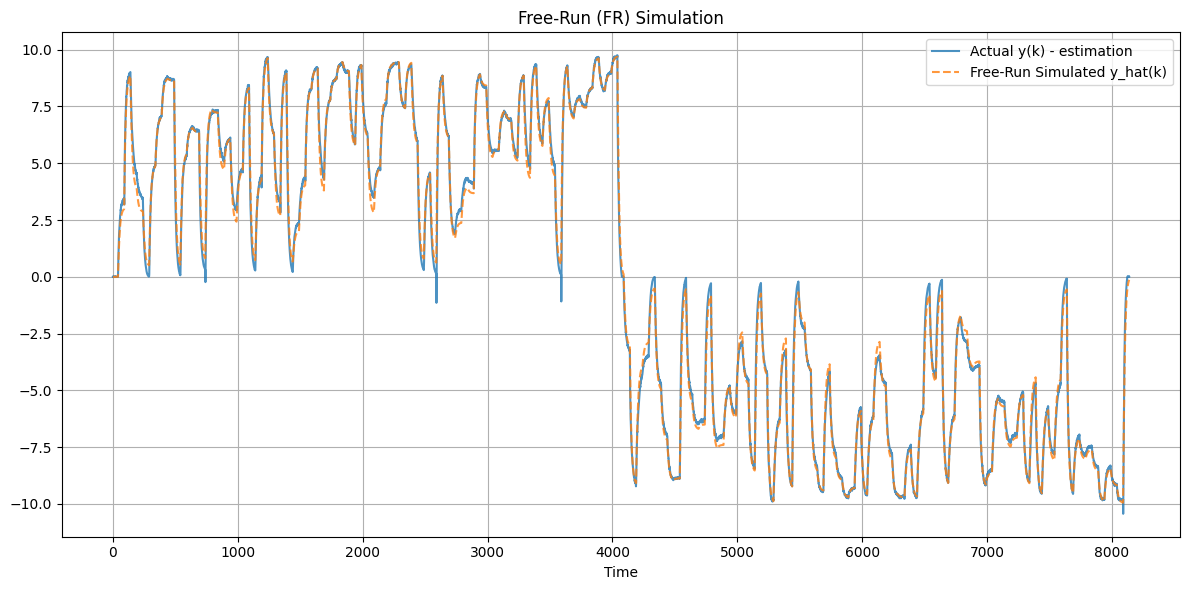

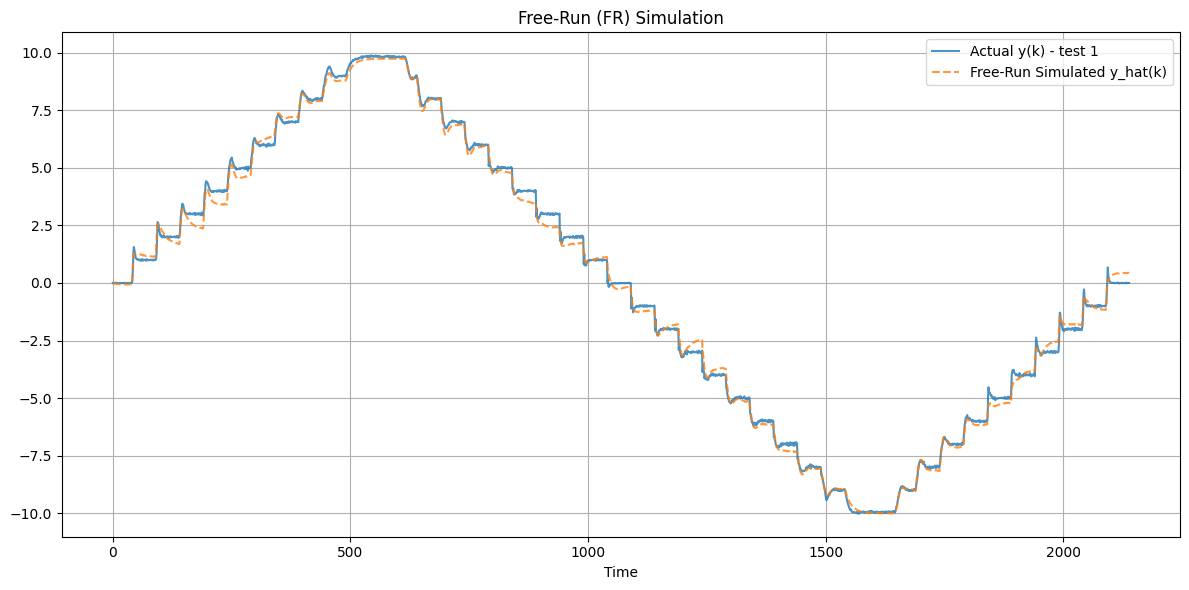

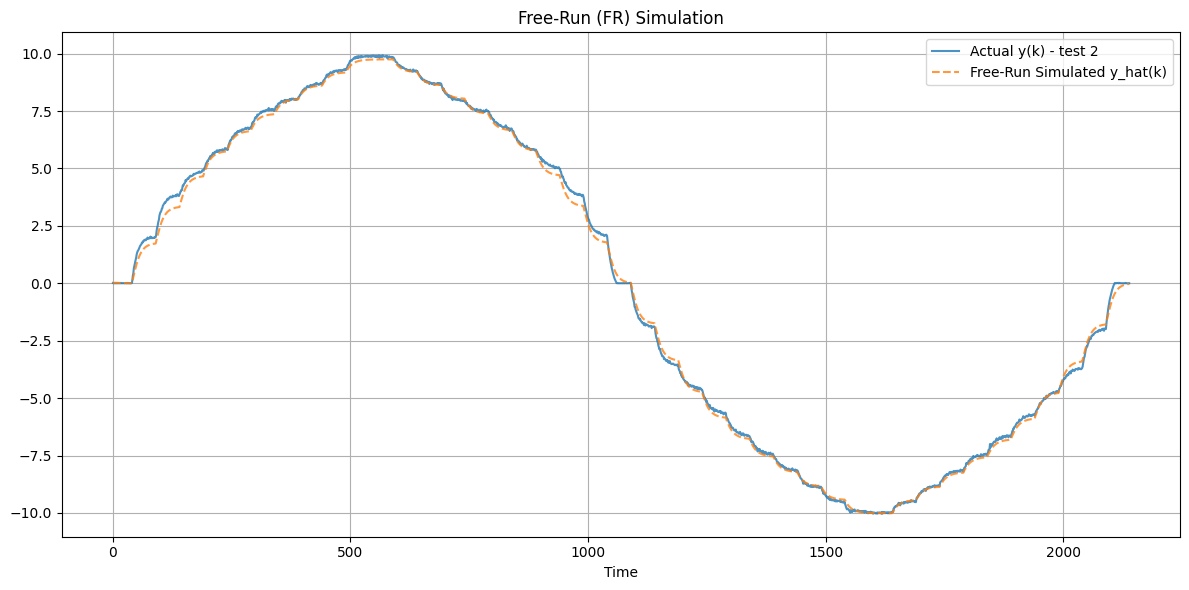

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(ye_fr, label='Actual y(k) - estimation', alpha=0.8)
plt.plot(ye_hat, label='Free-Run Simulated y_hat(k)', linestyle='--', alpha=0.8)
plt.title(f'Free-Run (FR) Simulation')
plt.xlabel(f'Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(yt1_fr, label='Actual y(k) - test 1', alpha=0.8)
plt.plot(yt1_hat, label='Free-Run Simulated y_hat(k)', linestyle='--', alpha=0.8)
plt.title(f'Free-Run (FR) Simulation')
plt.xlabel(f'Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(yt2_fr, label='Actual y(k) - test 2', alpha=0.8)
plt.plot(yt2_hat, label='Free-Run Simulated y_hat(k)', linestyle='--', alpha=0.8)
plt.title(f'Free-Run (FR) Simulation')
plt.xlabel(f'Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
